In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


Task 1: Dataset Preparation

In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()


In [3]:
X = data.data
Y = data.target

In [4]:
print(X.shape)
print(Y.shape)

(20640, 8)
(20640,)


In [5]:
np.random.seed(9432)

n = X.shape[0]


indices = np.random.permutation(n)

train_end = int(0.60 * n)
val_end = int(0.80 * n)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

X_train = X[train_indices]
y_train = Y[train_indices]

X_val = X[val_indices]
y_val = Y[val_indices]

X_test = X[test_indices]
y_test = Y[test_indices]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (12384, 8) (12384,)
Validation: (4128, 8) (4128,)
Test: (4128, 8) (4128,)


In [6]:
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)

X_train = (X_train - mean_train) / std_train
X_val = (X_val - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

print("Training mean:")
print(np.mean(X_train, axis=0))

print("\nTraining standard deviation:")
print(np.std(X_train, axis=0))

Training mean:
[ 6.67028520e-15 -4.05687721e-17 -1.97551946e-15 -9.56487359e-15
 -1.04742335e-16  1.83242942e-15  2.76463194e-14 -1.64395485e-13]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_val = np.hstack((np.ones((X_val.shape[0], 1)), X_val))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (12384, 9)
X_val shape: (4128, 9)
X_test shape: (4128, 9)


In [8]:
y_mean_train = np.mean(y_train)
y_std_train = np.std(y_train)

y_train_std = (y_train - y_mean_train)/y_std_train
y_val_std = (y_val - y_mean_train)/ y_std_train
y_test_std = (y_test - y_mean_train)/y_std_train

print("Original Training Target Mean:")
print(y_mean_train)

print("Original Training Target Std:")
print(y_std_train)

print("\nStandardized Training Target Mean:")
print(np.mean(y_train_std))

print("Standardized Training Target Std:")
print(np.std(y_train_std))

Original Training Target Mean:
2.058294566375969
Original Training Target Std:
1.1574139487531678

Standardized Training Target Mean:
9.78258530742063e-17
Standardized Training Target Std:
0.9999999999999999


Task 2: Implement Mini-Batch Gradient Descent

In [9]:
# define MSE function

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [10]:
# Implement Mini-Batch Gradient Descent
def mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    batch_size,
    max_epochs=1000,
    patience=100
):

    n_samples = X_train.shape[0]
    n_features = X_train.shape[1]

    weights = np.zeros(n_features)

    train_losses = []
    val_losses = []

    best_weights = weights.copy()
    best_val_loss = np.inf
    best_epoch = 0

    no_improvement = 0

    for epoch in range(max_epochs):

        indices = np.random.permutation(n_samples)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        total_loss = 0
        total_samples = 0

        for start in range(0, n_samples, batch_size):

            end = min(start + batch_size, n_samples)

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            m = len(X_batch)

            y_pred = X_batch @ weights

            error = y_pred - y_batch

            batch_loss = np.mean(error ** 2)

            gradient = (2 / m) * (X_batch.T @ error)

            weights = weights - learning_rate * gradient

            total_loss += batch_loss * m
            total_samples += m

        train_loss = total_loss / total_samples

        val_pred = X_val @ weights

        val_loss = mse(y_val, val_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_weights = weights.copy()
            best_epoch = epoch + 1

            no_improvement = 0

        else:
            no_improvement += 1

        if no_improvement >= patience:
            break

    return (
        best_weights,
        train_losses,
        val_losses,
        best_epoch,
        best_val_loss
    )

In [11]:
# Test the function
weights, train_loss, val_loss, best_epoch, best_val_loss = mini_batch_gradient_descent(
    X_train,
    y_train_std,
    X_val,
    y_val_std,
    learning_rate=0.001,
    batch_size=128
)

print("Best Epoch:", best_epoch)
print("Best Validation MSE:", best_val_loss)

Best Epoch: 293
Best Validation MSE: 0.3916782667777206


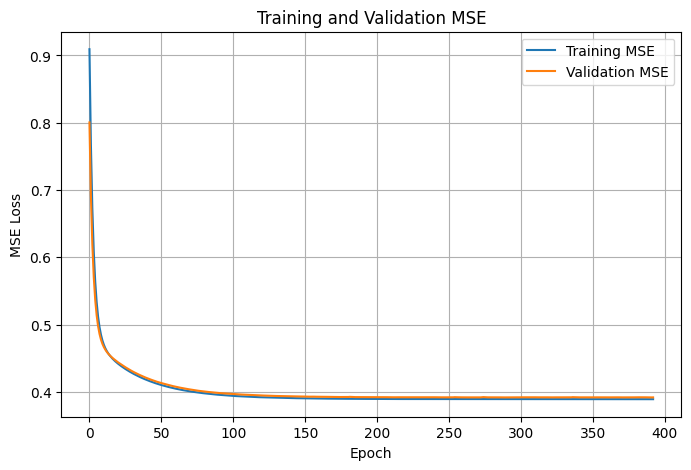

In [12]:
# Plot Training vs Validation MSE

plt.figure(figsize=(8, 5))

plt.plot(train_loss, label="Training MSE")
plt.plot(val_loss, label="Validation MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation MSE")
plt.legend()
plt.grid(True)

plt.show()

Task - 3

In [13]:
# different learning rates
learning_rates = [10**-5, 10**-4, 10**-3, 10**-2, 10**-1, 1, 10]
batch_size = 128

In [14]:
# now by all learning rate do experiments

lr_results = {}

for lr in learning_rates:

    print("Learning Rate:", lr)

    weights, train_loss, val_loss, best_epoch, best_val_loss = mini_batch_gradient_descent(
        X_train,
        y_train_std,
        X_val,
        y_val_std,
        learning_rate=lr,
        batch_size=128
    )

    lr_results[lr] = {
        "weights": weights,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

    print("Best Validation MSE:", best_val_loss)
    print("Best Epoch:", best_epoch)
    print()

Learning Rate: 1e-05
Best Validation MSE: 0.47149194234807135
Best Epoch: 1000

Learning Rate: 0.0001
Best Validation MSE: 0.3968411155139817
Best Epoch: 1000

Learning Rate: 0.001
Best Validation MSE: 0.391701180245949
Best Epoch: 276

Learning Rate: 0.01
Best Validation MSE: 0.39028409549873794
Best Epoch: 329

Learning Rate: 0.1


/tmp/ipykernel_3201/61236870.py:4: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_3201/3479499310.py:50: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(error ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_3201/3479499310.py:52: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / m) * (X_batch.T @ error)
/tmp/ipykernel_3201/3479499310.py:46: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ weights
/tmp/ipykernel_3201/3479499310.py:52: RuntimeWarning: invalid value encountered in matmul
  gradient = (2 / m) * (X_batch.T @ error)


Best Validation MSE: 1.177400153115955
Best Epoch: 1

Learning Rate: 1
Best Validation MSE: 2.346198147776598e+90
Best Epoch: 1

Learning Rate: 10
Best Validation MSE: inf
Best Epoch: 0



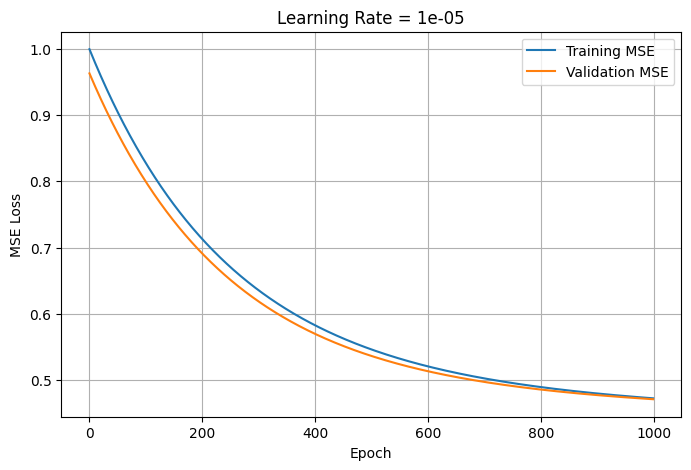

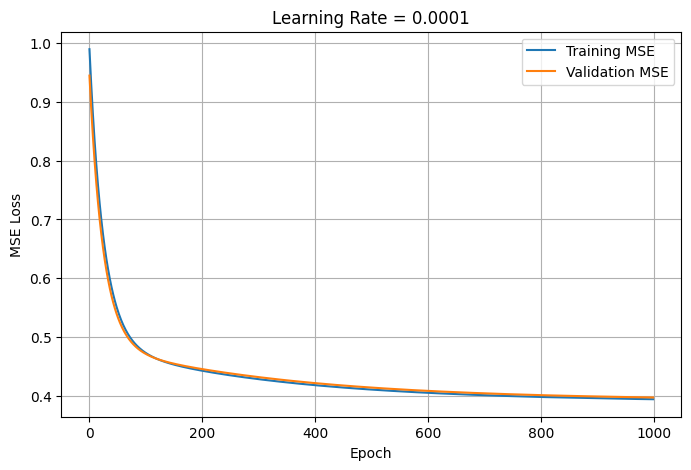

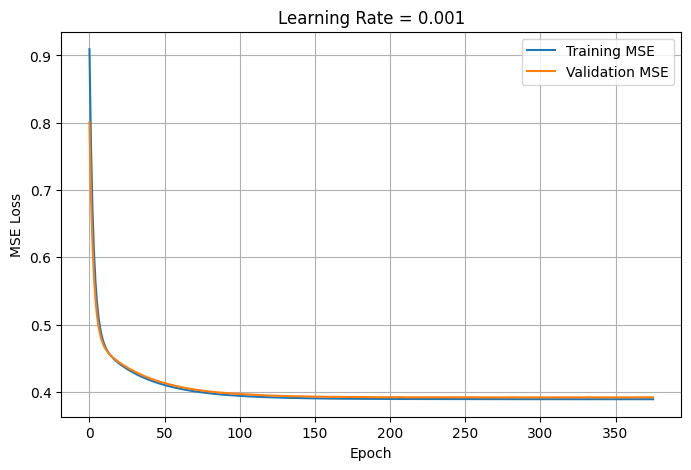

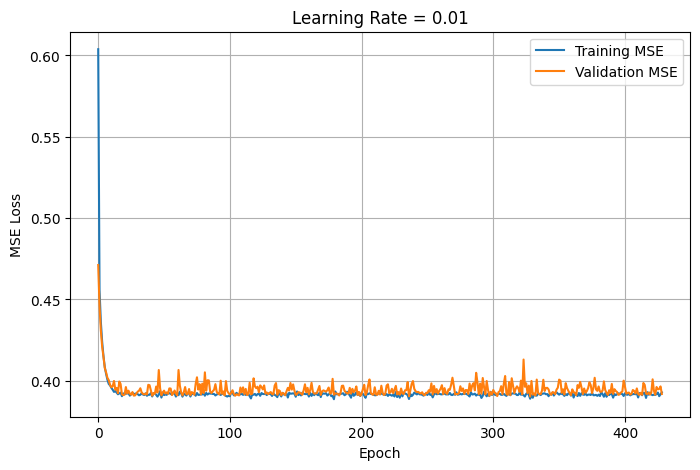

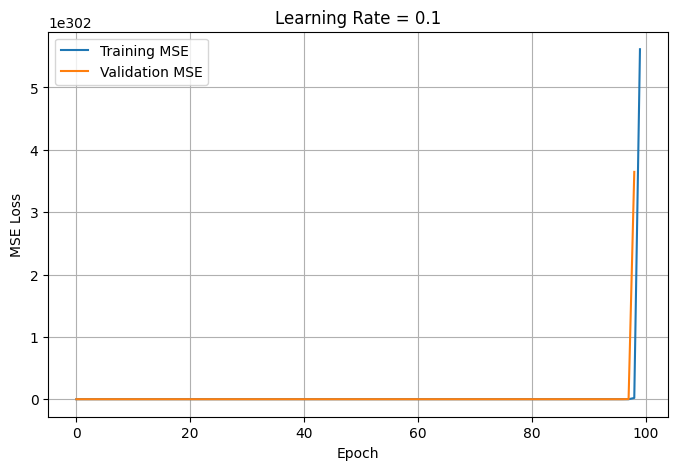

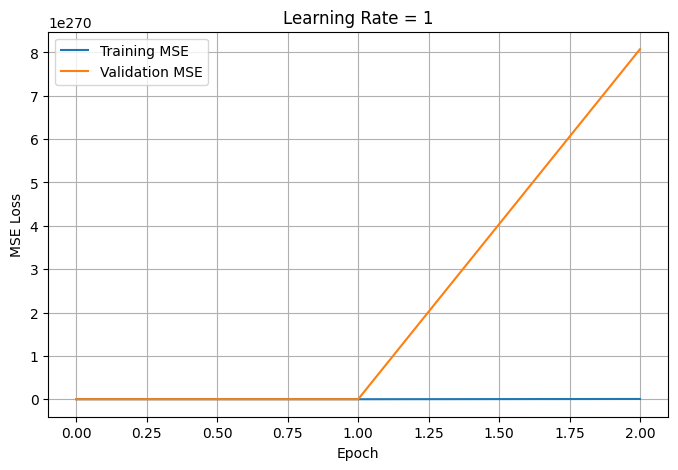

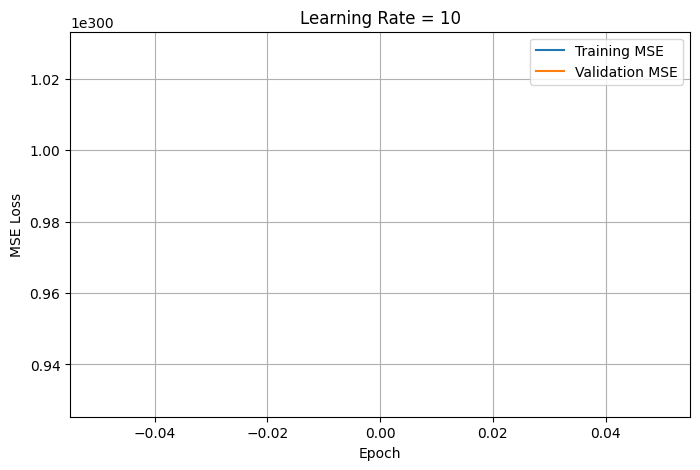

In [15]:
# plot all graphs

for lr in learning_rates:

    result = lr_results[lr]

    plt.figure(figsize=(8, 5))

    plt.plot(result["train_loss"], label="Training MSE")
    plt.plot(result["val_loss"], label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {lr}")

    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
# select best learning rate

best_lr = min(
    lr_results,
    key=lambda lr: lr_results[lr]["best_val_loss"]
)

print("Best Learning Rate:", best_lr)
print("Best Validation MSE:", lr_results[best_lr]["best_val_loss"])
print("Best Epoch:", lr_results[best_lr]["best_epoch"])

Best Learning Rate: 0.01
Best Validation MSE: 0.39028409549873794
Best Epoch: 329


Task 4: Effect of Batch Size

In [17]:
batch_sizes = [1, 16, 32, 64, 128, 256, X_train.shape[0]]


In [18]:
# run all batch size

batch_results = {}

for batch_size in batch_sizes:

    print("Batch Size:", batch_size)

    weights, train_loss, val_loss, best_epoch, best_val_loss = mini_batch_gradient_descent(
        X_train,
        y_train_std,
        X_val,
        y_val_std,
        learning_rate=best_lr,
        batch_size=batch_size
    )

    batch_results[batch_size] = {
        "weights": weights,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

    print("Best Validation MSE:", best_val_loss)
    print("Best Epoch:", best_epoch)
    print()

Batch Size: 1


/tmp/ipykernel_3201/3479499310.py:56: RuntimeWarning: overflow encountered in scalar add
  total_loss += batch_loss * m
/tmp/ipykernel_3201/61236870.py:4: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_3201/3479499310.py:50: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(error ** 2)


Best Validation MSE: 6611979.324653328
Best Epoch: 1

Batch Size: 16
Best Validation MSE: 44.84838393235832
Best Epoch: 1

Batch Size: 32
Best Validation MSE: 2.3468768451378725
Best Epoch: 1

Batch Size: 64
Best Validation MSE: 0.3902331033254332
Best Epoch: 125

Batch Size: 128
Best Validation MSE: 0.39062317653974693
Best Epoch: 29

Batch Size: 256
Best Validation MSE: 0.3908634116131121
Best Epoch: 159

Batch Size: 12384
Best Validation MSE: 0.39639576933149434
Best Epoch: 1000



In [19]:
# Create Batch Size Results Table

batch_table = pd.DataFrame({
    "Batch Size": batch_sizes,
    "Lowest Validation MSE": [
        batch_results[b]["best_val_loss"]
        for b in batch_sizes
    ],
    "Best Epoch": [
        batch_results[b]["best_epoch"]
        for b in batch_sizes
    ]
})

batch_table

,Batch Size,Lowest Validation MSE,Best Epoch
0,1,6.611979e+06,1
1,16,4.484838e+01,1
2,32,2.346877e+00,1
3,64,3.902331e-01,125
4,128,3.906232e-01,29
5,256,3.908634e-01,159
6,12384,3.963958e-01,1000


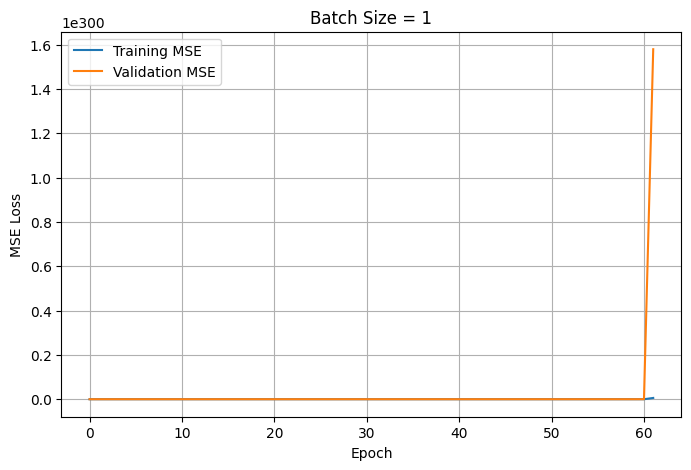

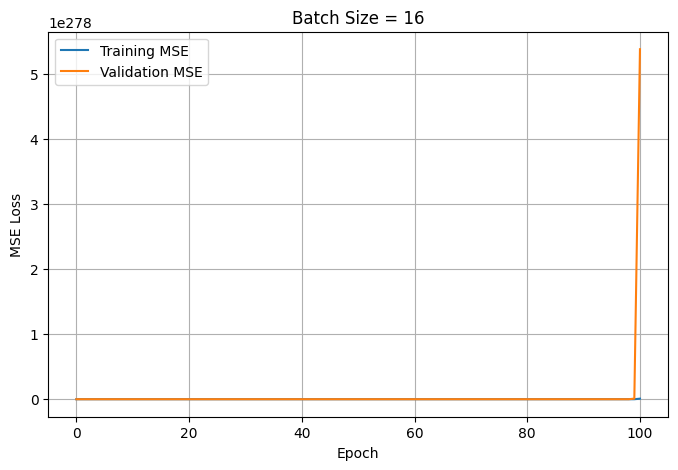

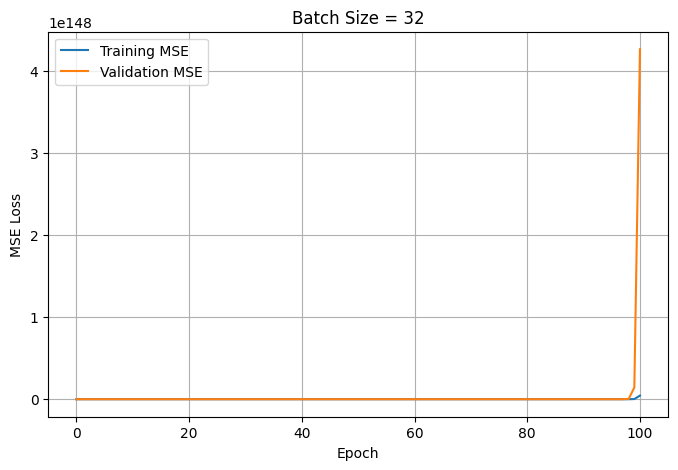

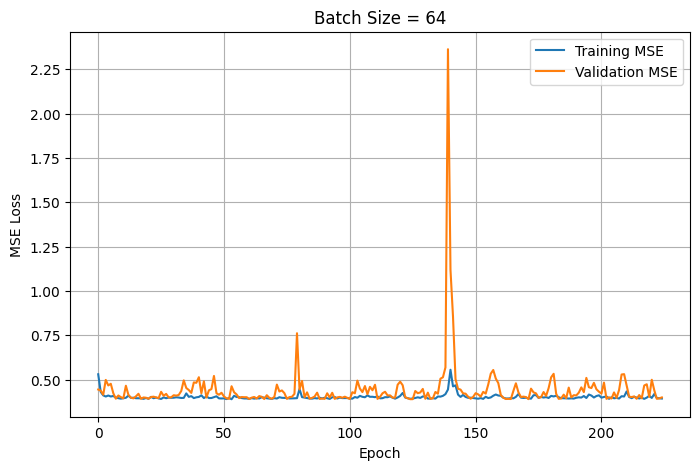

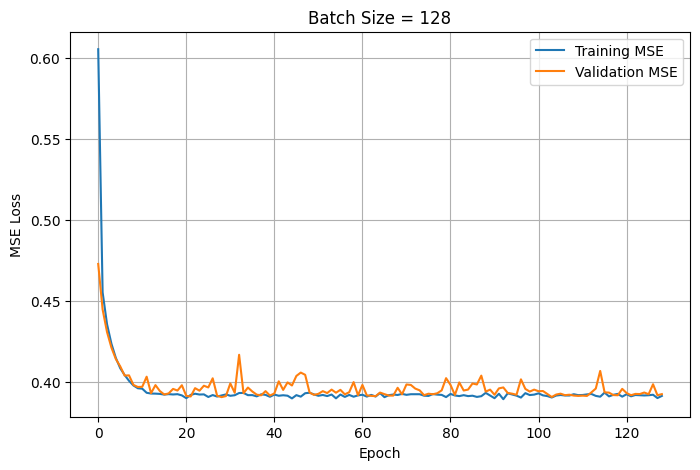

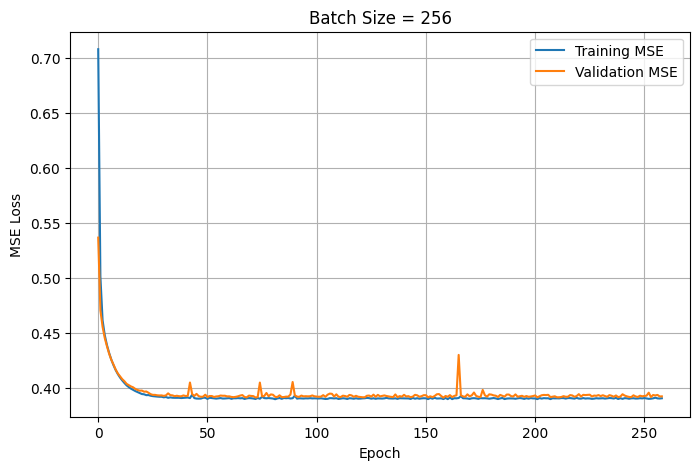

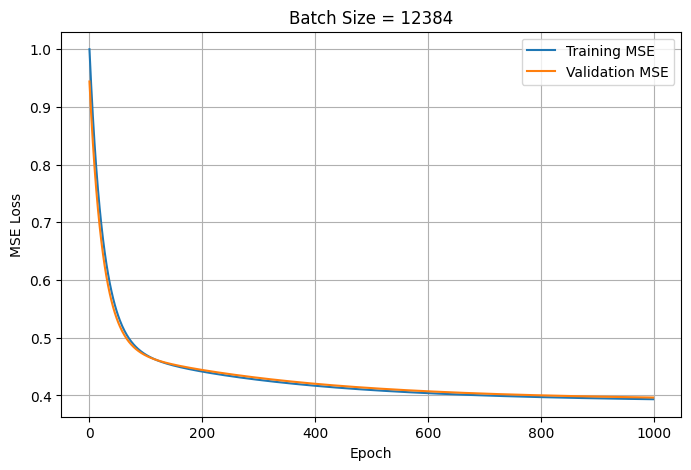

In [20]:
# Plot all Batch Size Curves
for batch_size in batch_sizes:

    result = batch_results[batch_size]

    plt.figure(figsize=(8, 5))

    plt.plot(result["train_loss"], label="Training MSE")
    plt.plot(result["val_loss"], label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {batch_size}")

    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
# Find Best Batch Size

best_batch_size = min(
    batch_results,
    key=lambda b: batch_results[b]["best_val_loss"]
)

print("Best Batch Size:", best_batch_size)
print("Best Validation MSE:", batch_results[best_batch_size]["best_val_loss"])
print("Best Epoch:", batch_results[best_batch_size]["best_epoch"])

Best Batch Size: 64
Best Validation MSE: 0.3902331033254332
Best Epoch: 125


Task 5: Inference on Test Set

In [22]:
# Get Final Best Model

best_weights = batch_results[best_batch_size]["weights"]

In [23]:
# Prediction Function

def predict_original(X, weights):

    y_pred_std = X @ weights

    y_pred = (y_pred_std * y_std_train) + y_mean_train

    return y_pred

In [24]:
# Generate Predictions

y_train_pred = predict_original(X_train, best_weights)
y_val_pred = predict_original(X_val, best_weights)
y_test_pred = predict_original(X_test, best_weights)

In [25]:
#  Define Evaluation Metrics

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100


def r_squared(y_true, y_pred):

    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_tot)

In [26]:
# Final Metrics Table

metrics_table = pd.DataFrame({

    "Dataset": [
        "Training",
        "Validation",
        "Test"
    ],

    "RMSE": [
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred),
        rmse(y_test, y_test_pred)
    ],

    "MAPE (%)": [
        mape(y_train, y_train_pred),
        mape(y_val, y_val_pred),
        mape(y_test, y_test_pred)
    ],

    "MAE": [
        mae(y_train, y_train_pred),
        mae(y_val, y_val_pred),
        mae(y_test, y_test_pred)
    ],

    "R-Squared": [
        r_squared(y_train, y_train_pred),
        r_squared(y_val, y_val_pred),
        r_squared(y_test, y_test_pred)
    ]
})

metrics_table

,Dataset,RMSE,MAPE (%),MAE,R-Squared
0,Training,0.722797,31.498188,0.527584,0.610008
1,Validation,0.723021,31.338710,0.532450,0.595381
2,Test,0.730868,31.221336,0.531670,0.603067


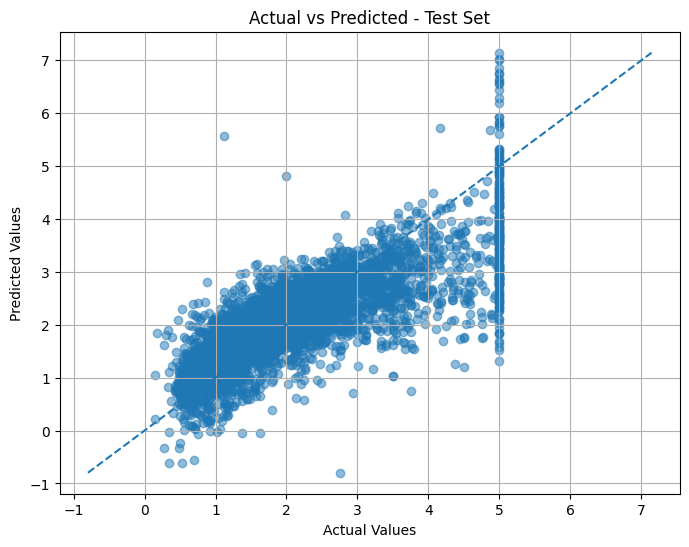

In [27]:
# Actual vs Predicted Plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Test Set")

plt.grid(True)
plt.show()